# Programming Assignment 3: Deep Q-Network for Acrobot (Optimized v2)

This notebook presents a fully self-contained DQN workflow with runtime and clarity improvements while preserving fair evaluation.

**Cell note:** This opening cell defines scope, optimization goals, and what evidence to expect from the run outputs.

## Update Notes (v2)
- Added explicit run-mode controls (`RUN_TRAINING`, `USE_CACHE`, `LOG_INTERVAL`) for quicker iteration.
- Replay-buffer sampling now uses `torch.from_numpy(...)` to reduce tensor-conversion overhead.
- Training updates are configurable with `train_every` to control compute pressure.
- Consolidated summary/comparison logic into reusable helper functions.
- Added interpretation cells that explain what the resulting metrics mean.

**Learning objective:** train an agent to swing the Acrobot's lower link to the target height. Since each step gives reward `-1`, higher (less negative) return and shorter episodes indicate better control.

In [1]:
# Initialize libraries, reproducibility settings, directories, and hyperparameters.
# All later cells depend on this configuration block and its generated paths.
import random
import time
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = Path.cwd()
ASSIGNMENT_DIR = BASE_DIR if BASE_DIR.name == "Assignment_3" else BASE_DIR / "Assignment_3"
OUTPUT_DIR = ASSIGNMENT_DIR / "optimized_outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "seed": SEED,
    "num_episodes": 300,
    "max_steps": 500,
    "eval_interval": 25,
    "eval_episodes": 10,
    "moving_average_window": 25,
    "efficiency_threshold": -200.0,
    "gamma": 0.99,
    "learning_rate": 5e-4,
    "batch_size": 128,
    "hidden_dim": 128,
    "replay_capacity": 100_000,
    "learning_starts": 1_000,
    "tau": 0.005,
    "grad_clip": 10.0,
    "epsilon_start": 1.0,
    "epsilon_min": 0.02,
    "epsilon_decay": 0.97,
    "train_every": 1
}

RUN_TRAINING = True
USE_CACHE = not RUN_TRAINING
LOG_INTERVAL = 25

print(f"Device: {DEVICE}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")
display(pd.Series(CONFIG, name="value").to_frame())

Device: cpu
Output directory: C:\Github\RL-AI572\Assignment_3\optimized_outputs


,value
seed,42.0000
num_episodes,300.0000
max_steps,500.0000
eval_interval,25.0000
eval_episodes,10.0000
moving_average_window,25.0000
efficiency_threshold,-200.0000
gamma,0.9900
learning_rate,0.0005
batch_size,128.0000


## 1. Inspect the Environment
Quick sanity check of Acrobot observation/action spaces.

**Cell note:** This section verifies the state representation and action count before training. If these values are unexpected, downstream model dimensions will be incorrect.

In [2]:
# Cell note: Validate environment interfaces before creating the neural network.
# Output from this cell confirms the observation vector shape and discrete action count.
env = gym.make("Acrobot-v1")
observation, _ = env.reset(seed=SEED)
env.action_space.seed(SEED)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Observation shape:", observation.shape)
print("Example observation:", np.round(observation, 3))
env.close()

Observation space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
Action space: Discrete(3)
Observation shape: (6,)
Example observation: [ 0.998  0.055  1.    -0.012  0.072  0.039]


## 2. DQN Implementation
Double DQN targets, replay, soft target updates, and configurable training frequency.


In [3]:
# Define the complete DQN pipeline in one place for readability and reuse.
# The key outputs are `train_dqn(...)`, `evaluate(...)`, and model/replay abstractions.
class ReplayBuffer:
    """Circular replay memory with O(1) overwrite and random sampling."""

    def __init__(self, capacity):
        self.capacity = capacity
        self.data = []
        self.position = 0

    def add(self, *transition):
        if len(self.data) < self.capacity:
            self.data.append(transition)
        else:
            self.data[self.position] = transition
        self.position = (self.position + 1) % self.capacity

    def sample(self, size):
        states, actions, rewards, next_states, dones = zip(*random.sample(self.data, size))
        states_np = np.asarray(states, dtype=np.float32)
        next_states_np = np.asarray(next_states, dtype=np.float32)
        actions_np = np.asarray(actions, dtype=np.int64)
        rewards_np = np.asarray(rewards, dtype=np.float32)
        dones_np = np.asarray(dones, dtype=np.float32)
        return (
            torch.from_numpy(states_np).to(DEVICE),
            torch.from_numpy(actions_np).to(DEVICE),
            torch.from_numpy(rewards_np).to(DEVICE),
            torch.from_numpy(next_states_np).to(DEVICE),
            torch.from_numpy(dones_np).to(DEVICE),
        )

    def __len__(self):
        return len(self.data)


class DQN(nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, state):
        return self.net(state)


def action_for(network, state, epsilon, action_dim):
    if np.random.random() < epsilon:
        return int(np.random.randint(action_dim))
    with torch.no_grad():
        state_t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        return int(network(state_t).argmax())


def evaluate(network, env, episodes, max_steps):
    """Run greedy-policy evaluation and return episode-level reward/length/success metrics."""
    results = []
    for _ in range(episodes):
        state, _ = env.reset()
        total_reward, terminated, step = 0.0, False, 0
        for step in range(max_steps):
            action = action_for(network, state, epsilon=0.0, action_dim=env.action_space.n)
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            if terminated or truncated:
                break
        results.append((total_reward, step + 1, int(terminated)))
    return np.asarray(results)


def learn(policy, target, optimizer, memory, config):
    """Perform one Double-DQN optimization step with Huber loss and soft target update."""
    states, actions, rewards, next_states, dones = memory.sample(config["batch_size"])
    q_current = policy(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        next_actions = policy(next_states).argmax(dim=1, keepdim=True)
        q_next = target(next_states).gather(1, next_actions).squeeze(1)
        q_target = rewards + config["gamma"] * q_next * (1 - dones)
    loss = F.smooth_l1_loss(q_current, q_target)
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(policy.parameters(), config["grad_clip"])
    optimizer.step()
    with torch.no_grad():
        for target_param, param in zip(target.parameters(), policy.parameters()):
            target_param.mul_(1 - config["tau"]).add_(config["tau"] * param)
    return float(loss.item())


def train_dqn(config, use_cache=False, log_interval=25):
    """Train DQN or load cached outputs, then return policy and training/evaluation logs."""
    if use_cache:
        results_path = OUTPUT_DIR / "cleaned_episode_results.csv"
        checkpoint_path = OUTPUT_DIR / "checkpoint_success.csv"
        if results_path.exists() and checkpoint_path.exists():
            print(f"Loading cached training results from {OUTPUT_DIR}")
            return None, pd.read_csv(results_path), pd.read_csv(checkpoint_path), float("nan")
        print("No cache found. Training from scratch.")

    random.seed(config["seed"])
    np.random.seed(config["seed"])
    torch.manual_seed(config["seed"])

    train_env = gym.make("Acrobot-v1")
    eval_env = gym.make("Acrobot-v1")

    state_dim = train_env.observation_space.shape[0]
    action_dim = train_env.action_space.n

    policy = DQN(state_dim, config["hidden_dim"], action_dim).to(DEVICE)
    target = DQN(state_dim, config["hidden_dim"], action_dim).to(DEVICE)
    target.load_state_dict(policy.state_dict())

    optimizer = optim.Adam(policy.parameters(), lr=config["learning_rate"])
    memory = ReplayBuffer(config["replay_capacity"])
    epsilon = config["epsilon_start"]

    records = []
    checkpoints = []
    start_time = time.time()

    for episode in range(1, config["num_episodes"] + 1):
        state, _ = train_env.reset(seed=config["seed"] + episode)
        total_reward, success = 0.0, 0
        step_losses = []

        for step in range(config["max_steps"]):
            action = action_for(policy, state, epsilon, action_dim)
            next_state, reward, terminated, truncated, _ = train_env.step(action)
            memory.add(state, action, float(reward), next_state, float(terminated))
            state = next_state
            total_reward += reward

            if len(memory) >= config["learning_starts"] and step % config["train_every"] == 0:
                step_losses.append(learn(policy, target, optimizer, memory, config))

            if terminated:
                success = 1
                break
            if truncated:
                break

        records.append((
            episode,
            total_reward,
            step + 1,
            success,
            epsilon,
            np.mean(step_losses) if step_losses else np.nan
        ))

        epsilon = max(config["epsilon_min"], epsilon * config["epsilon_decay"])

        if episode % config["eval_interval"] == 0:
            eval_values = evaluate(policy, eval_env, config["eval_episodes"], config["max_steps"])
            checkpoints.append((episode, 100 * eval_values[:, 2].mean(), eval_values[:, 0].mean()))

        if episode % log_interval == 0:
            latest_success = checkpoints[-1][1] if checkpoints else float("nan")
            latest_eval = checkpoints[-1][2] if checkpoints else float("nan")
            print(
                f"Episode {episode:3d}: train reward={total_reward:7.1f}, eps={epsilon:.3f}, "
                f"greedy reward={latest_eval:7.1f}, success={latest_success:5.1f}%"
            )

    train_env.close()
    eval_env.close()

    training_df = pd.DataFrame(records, columns=["episode", "reward", "length", "success", "epsilon", "loss"])
    checkpoint_df = pd.DataFrame(checkpoints, columns=["episode", "success_rate_pct", "mean_reward"])
    return policy, training_df, checkpoint_df, time.time() - start_time

## 3. Train the Agent

**Cell note:** This stage executes training once (or loads cached artifacts) and creates `training_df` and `checkpoint_df`, which all later analyses depend on.

In [4]:
# Launch training and capture the main dataframes used by all remaining sections.
# `training_df` stores per-episode logs, while `checkpoint_df` stores periodic greedy evaluations.
policy_net, training_df, checkpoint_df, training_seconds = train_dqn(CONFIG, use_cache=USE_CACHE, log_interval=LOG_INTERVAL)
if np.isnan(training_seconds):
    print(f"Episodes logged: {len(training_df)} | Training time: n/a (loaded from cache)")
else:
    print(f"Episodes logged: {len(training_df)} | Training time: {training_seconds:.1f}s")
display(training_df.head())

Episode  25: train reward= -160.0, eps=0.467, greedy reward= -500.0, success=  0.0%
Episode  50: train reward=  -86.0, eps=0.218, greedy reward= -461.3, success= 10.0%
Episode  75: train reward= -137.0, eps=0.102, greedy reward= -500.0, success=  0.0%
Episode 100: train reward= -125.0, eps=0.048, greedy reward= -111.5, success=100.0%
Episode 125: train reward=  -95.0, eps=0.022, greedy reward= -101.4, success=100.0%
Episode 150: train reward=  -91.0, eps=0.020, greedy reward=  -82.9, success=100.0%
Episode 175: train reward=  -79.0, eps=0.020, greedy reward=  -88.4, success=100.0%
Episode 200: train reward=  -81.0, eps=0.020, greedy reward=  -79.5, success=100.0%
Episode 225: train reward=  -66.0, eps=0.020, greedy reward=  -77.9, success=100.0%
Episode 250: train reward=  -75.0, eps=0.020, greedy reward=  -91.5, success=100.0%
Episode 275: train reward=  -72.0, eps=0.020, greedy reward=  -75.9, success=100.0%
Episode 300: train reward=  -73.0, eps=0.020, greedy reward=  -80.5, success

,episode,reward,length,success,epsilon,loss
0,1,-500.0,500,0,1.000000,NaN
1,2,-500.0,500,0,0.970000,0.432954
2,3,-500.0,500,0,0.940900,0.013022
3,4,-500.0,500,0,0.912673,0.000542
4,5,-500.0,500,0,0.885293,0.000804


## 4. Statistics and Dashboard

**Cell note:** This section summarizes central tendencies, visualizes learning curves, and computes sample-efficiency indicators for assignment discussion.

,count,mean,std,min,10%,25%,50%,75%,90%,max
reward,300.0,-120.083333,93.319943,-500.000000,-174.300000,-110.500000,-91.000000,-77.750000,-71.000000,-61.000000
length,300.0,121.040000,93.142993,62.000000,72.000000,78.750000,92.000000,111.500000,175.300000,500.000000
success,300.0,0.956667,0.203947,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
epsilon,300.0,0.120327,0.205597,0.020000,0.020000,0.020000,0.020000,0.102618,0.402247,1.000000
loss,299.0,0.317822,0.155593,0.000542,0.066398,0.195361,0.338149,0.450185,0.502905,0.586318


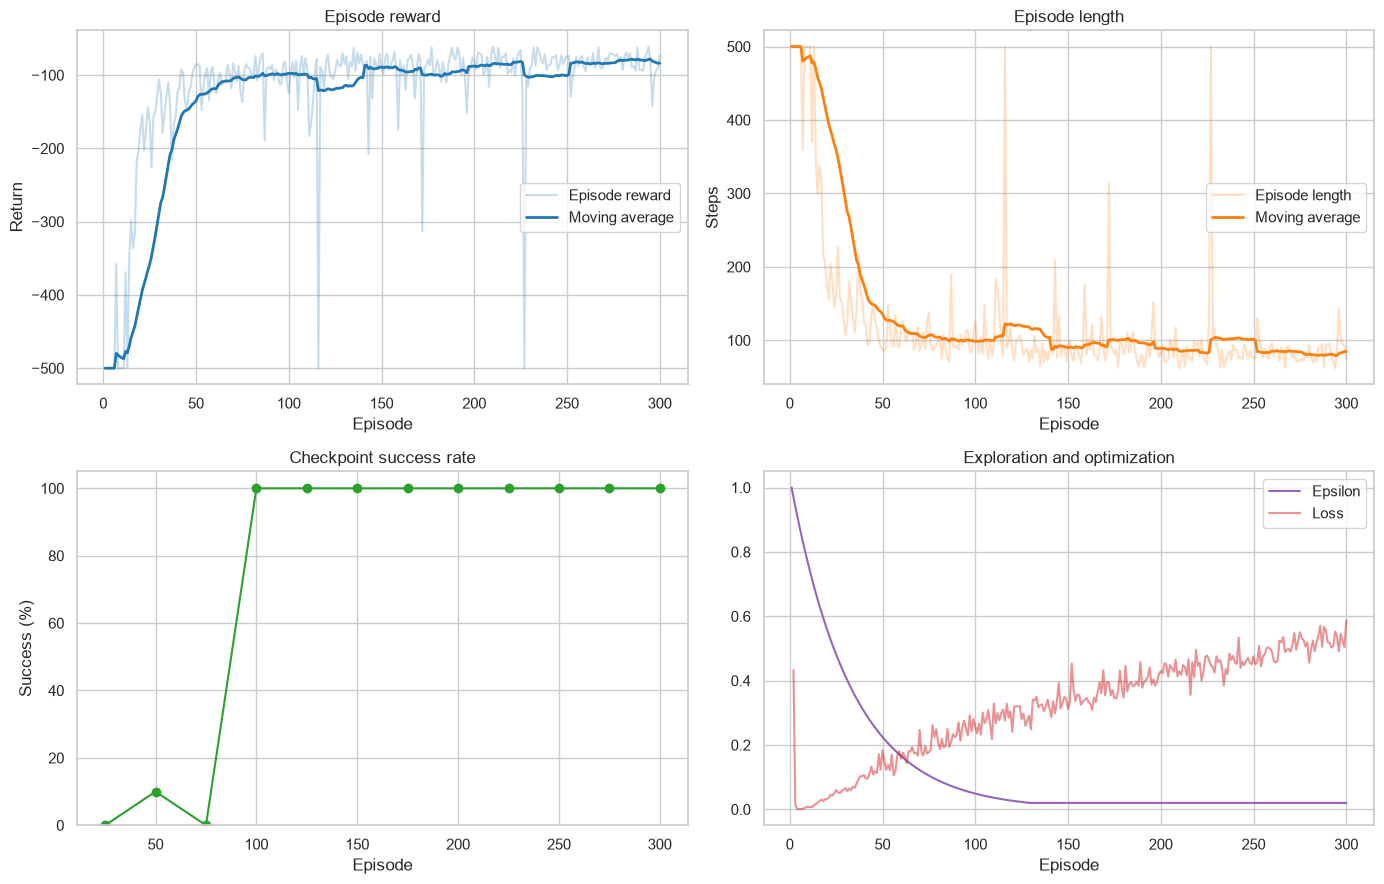

Best 25-episode moving-average reward: -78.28
Sample efficiency: episode 38


In [5]:
# uild descriptive statistics and a reusable dashboard figure for training diagnostics.
# The moving-average and threshold metrics provide compact evidence of learning progress.
stat_columns = ["reward", "length", "success", "epsilon"] + (["loss"] if "loss" in training_df else [])
descriptive_stats = training_df[stat_columns].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).T
display(descriptive_stats)

def plot_training_dashboard(training_df, checkpoint_df, cfg):
    """Create a four-panel training dashboard and return the matplotlib figure object."""
    window = cfg["moving_average_window"]
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    reward_ma = training_df.reward.rolling(window, min_periods=1).mean()
    length_ma = training_df.length.rolling(window, min_periods=1).mean()

    axes[0, 0].plot(training_df.episode, training_df.reward, alpha=0.25, color="tab:blue", label="Episode reward")
    axes[0, 0].plot(training_df.episode, reward_ma, color="tab:blue", linewidth=2, label="Moving average")
    axes[0, 0].set(title="Episode reward", xlabel="Episode", ylabel="Return")
    axes[0, 0].legend()

    axes[0, 1].plot(training_df.episode, training_df.length, alpha=0.25, color="tab:orange", label="Episode length")
    axes[0, 1].plot(training_df.episode, length_ma, color="tab:orange", linewidth=2, label="Moving average")
    axes[0, 1].set(title="Episode length", xlabel="Episode", ylabel="Steps")
    axes[0, 1].legend()

    if not checkpoint_df.empty:
        axes[1, 0].plot(checkpoint_df.episode, checkpoint_df.success_rate_pct, marker="o", color="tab:green")
    axes[1, 0].set(title="Checkpoint success rate", xlabel="Episode", ylabel="Success (%)", ylim=(0, 105))

    axes[1, 1].plot(training_df.episode, training_df.epsilon, color="tab:purple", label="Epsilon")
    if "loss" in training_df:
        axes[1, 1].plot(training_df.episode, training_df.loss, color="tab:red", alpha=0.5, label="Loss")
    axes[1, 1].set(title="Exploration and optimization", xlabel="Episode")
    axes[1, 1].legend()

    fig.tight_layout()
    return fig

dashboard_fig = plot_training_dashboard(training_df, checkpoint_df, CONFIG)
plt.show()

rewards_arr = training_df.reward.to_numpy(dtype=float)
ma_window = CONFIG["moving_average_window"]
if len(rewards_arr) >= ma_window:
    ma_rewards = np.convolve(rewards_arr, np.ones(ma_window) / ma_window, mode="valid")
    best_ma_reward = float(ma_rewards.max())
    threshold = CONFIG["efficiency_threshold"]
    sample_efficiency_ep = int(next((i + ma_window for i, v in enumerate(ma_rewards) if v >= threshold), -1))
else:
    best_ma_reward = float("nan")
    sample_efficiency_ep = -1

print(f"Best {ma_window}-episode moving-average reward: {best_ma_reward:.2f}")
print("Sample efficiency:", f"episode {sample_efficiency_ep}" if sample_efficiency_ep >= 0 else "not reached")

## 5. Relationship Analysis

**Cell note:** This section tests whether improved reward aligns with shorter episodes and rising success over training progression.

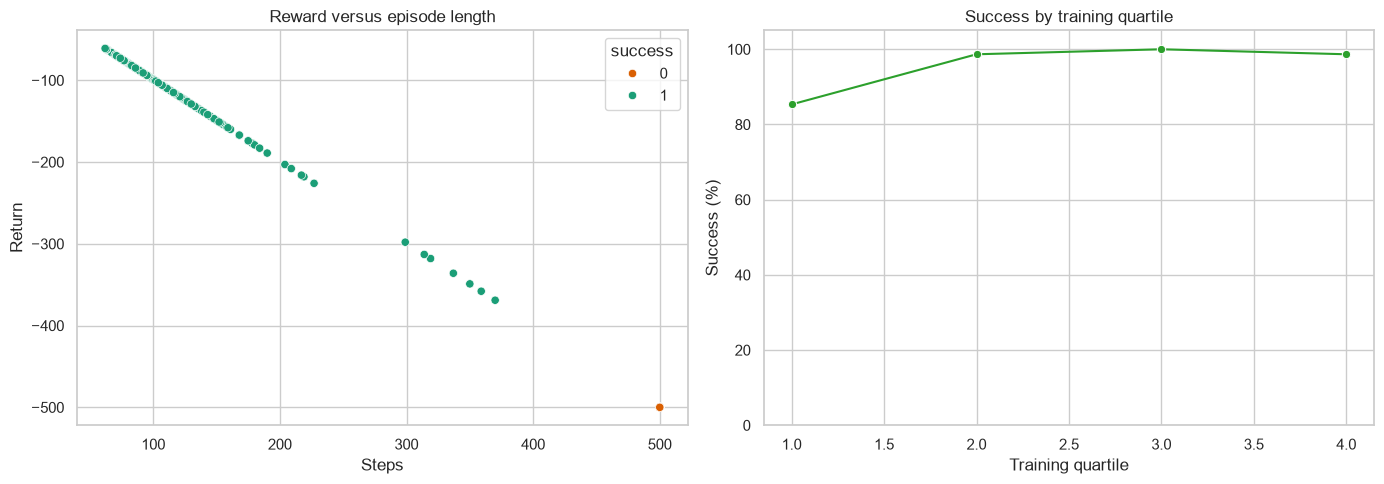

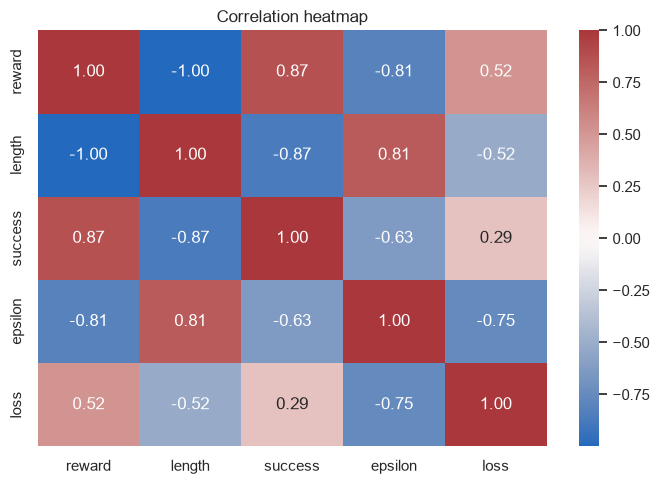

In [6]:
# Analyze metric relationships using quartiles, scatter trends, and correlation structure.
# These views help explain why reward changes, not just whether it changes.
relation_df = training_df.copy()
relation_df["training_quartile"] = pd.qcut(relation_df.episode, q=min(4, len(relation_df)), labels=False, duplicates="drop") + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=relation_df, x="length", y="reward", hue="success", palette={0: "#d95f02", 1: "#1b9e77"}, ax=axes[0])
axes[0].set(title="Reward versus episode length", xlabel="Steps", ylabel="Return")

grouped = relation_df.groupby("training_quartile", as_index=False).success.mean()
grouped["success_pct"] = 100 * grouped.success
sns.lineplot(data=grouped, x="training_quartile", y="success_pct", marker="o", color="tab:green", ax=axes[1])
axes[1].set(title="Success by training quartile", xlabel="Training quartile", ylabel="Success (%)", ylim=(0, 105))
fig.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(relation_df[stat_columns].corr(), annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

## 6. Final Greedy Evaluation and Artifact Export

**Cell note:** This section computes final no-exploration performance metrics and writes all required CSV/figure artifacts for reporting.

In [7]:
# Evaluate the final policy greedily, build a compact summary table, and export artifacts.
# Exported files are the reproducible record used by reports and comparisons.
if policy_net is not None:
    eval_env = gym.make("Acrobot-v1")
    final_eval_values = evaluate(policy_net, eval_env, episodes=30, max_steps=CONFIG["max_steps"])
    eval_env.close()
    dqn_eval_metrics = {
        "mean_reward": float(final_eval_values[:, 0].mean()),
        "std_reward": float(final_eval_values[:, 0].std()),
        "success_rate_pct": float(100 * final_eval_values[:, 2].mean()),
        "mean_episode_length": float(final_eval_values[:, 1].mean())
    }
else:
    dqn_eval_metrics = None

def build_summary(training_df, training_seconds, best_ma_reward, sample_efficiency_ep):
    """Assemble one-row run summary with performance, efficiency, and runtime metrics."""
    return pd.DataFrame([{
        "episodes": len(training_df),
        "mean_reward": training_df.reward.mean(),
        "last_window_mean_reward": training_df.reward.tail(CONFIG["moving_average_window"]).mean(),
        "best_ma_reward": best_ma_reward,
        "mean_length": training_df.length.mean(),
        "overall_success_pct": 100 * training_df.success.mean(),
        "sample_efficiency_ep": sample_efficiency_ep,
        "training_time_sec": training_seconds,
        "device": str(DEVICE)
    }])

summary_df = build_summary(training_df, training_seconds, best_ma_reward, sample_efficiency_ep)
display(summary_df)
if dqn_eval_metrics is not None:
    print(pd.Series(dqn_eval_metrics))
else:
    print("DQN greedy evaluation skipped because policy was loaded from cache without in-memory model.")

training_df.to_csv(OUTPUT_DIR / "cleaned_episode_results.csv", index=False)
checkpoint_df.to_csv(OUTPUT_DIR / "checkpoint_success.csv", index=False)
descriptive_stats.to_csv(OUTPUT_DIR / "descriptive_statistics.csv")
summary_df.to_csv(OUTPUT_DIR / "model_summary.csv", index=False)
dashboard_fig.savefig(FIGURES_DIR / "dqn_training_overview_v2.png", dpi=160, bbox_inches="tight")
print(f"Exported updated artifacts to {OUTPUT_DIR.resolve()}")

,episodes,mean_reward,last_window_mean_reward,best_ma_reward,mean_length,overall_success_pct,sample_efficiency_ep,training_time_sec,device
0,300,-120.083333,-83.68,-78.28,121.04,95.666667,38,146.927689,cpu


mean_reward            -85.066667
std_reward              26.596909
success_rate_pct       100.000000
mean_episode_length     86.066667
dtype: float64
Exported updated artifacts to C:\Github\RL-AI572\Assignment_3\optimized_outputs


## 7. Compare DQN vs Actor-Critic vs Q-Actor-Critic

**Cell note:** This section ranks algorithms using evaluation reward as the primary criterion and episode length as a secondary tie-breaker.

In [8]:
# Build a fair algorithm table and produce a data-driven winner statement.
# If DQN greedy evaluation is unavailable, a clear caveat is printed for transparency.
actor_summary = pd.read_csv(ASSIGNMENT_DIR.parent / "Assignment_2" / "summary_metrics_actor_critic.csv").iloc[0]
qac_summary = pd.read_csv(ASSIGNMENT_DIR.parent / "Assignment_2" / "summary_qac_optimized.csv").iloc[0]

if dqn_eval_metrics is not None:
    dqn_row = {
        "algorithm": "DQN",
        "evaluation_basis": "30 greedy episodes",
        "mean_reward": dqn_eval_metrics["mean_reward"],
        "success_rate_pct": dqn_eval_metrics["success_rate_pct"],
        "mean_episode_length": dqn_eval_metrics["mean_episode_length"]
    }
else:
    dqn_window = training_df.tail(CONFIG["moving_average_window"])
    dqn_row = {
        "algorithm": "DQN",
        "evaluation_basis": "final training window",
        "mean_reward": dqn_window.reward.mean(),
        "success_rate_pct": 100 * dqn_window.success.mean(),
        "mean_episode_length": dqn_window.length.mean()
    }

comparison_df = pd.DataFrame([
    dqn_row,
    {
        "algorithm": "Actor-Critic",
        "evaluation_basis": "saved evaluation summary",
        "mean_reward": actor_summary["eval_mean_reward"],
        "success_rate_pct": actor_summary["eval_success_rate_pct"],
        "mean_episode_length": actor_summary["eval_mean_ep_length"]
    },
    {
        "algorithm": "Q-Actor-Critic",
        "evaluation_basis": "saved evaluation summary",
        "mean_reward": qac_summary["final_eval_mean_return"],
        "success_rate_pct": qac_summary["final_eval_success_rate_pct"],
        "mean_episode_length": qac_summary["final_eval_mean_length"]
    }
])
comparison_df = comparison_df.sort_values("mean_reward", ascending=False).reset_index(drop=True)
comparison_df.to_csv(OUTPUT_DIR / "algorithm_comparison.csv", index=False)
display(comparison_df)

best = comparison_df.iloc[0]
runner_up = comparison_df.iloc[1]
print(
    f"Superior algorithm by mean evaluation reward: {best.algorithm} ({best.mean_reward:.2f}), "
    f"ahead of {runner_up.algorithm} ({runner_up.mean_reward:.2f}) by {best.mean_reward - runner_up.mean_reward:.2f} reward "
    f"and {runner_up.mean_episode_length - best.mean_episode_length:.1f} fewer steps per episode."
)
if comparison_df.success_rate_pct.nunique() == 1:
    print("All algorithms have the same success rate; reward and episode length become the tie-breakers.")
if dqn_eval_metrics is None:
    print("Caveat: DQN currently uses a training-window proxy. Set RUN_TRAINING = True for fair greedy evaluation.")

,algorithm,evaluation_basis,mean_reward,success_rate_pct,mean_episode_length
0,DQN,30 greedy episodes,-85.066667,100.0,86.066667
1,Actor-Critic,saved evaluation summary,-87.060000,100.0,88.100000
2,Q-Actor-Critic,saved evaluation summary,-160.390000,100.0,161.390000


Superior algorithm by mean evaluation reward: DQN (-85.07), ahead of Actor-Critic (-87.06) by 1.99 reward and 2.0 fewer steps per episode.
All algorithms have the same success rate; reward and episode length become the tie-breakers.


## 8. Result Review and Explanation

**Cell note:** This section interprets the executed results directly and can be used as report-ready discussion text.

### Overall Training Outcome

The final run completed **300 episodes** in about **146.9 seconds** on **CPU**. Across all training episodes, the agent achieved a mean reward of **-120.08**, a mean episode length of **121.04 steps**, and an overall success rate of **95.67%**. In Acrobot, reward is closer to zero when the agent reaches the goal in fewer steps, so these values indicate that the policy improved substantially over the course of training.

The last part of training was stronger than the run average. The mean reward over the final moving window was **-83.68**, while the best moving-average reward reached **-78.28**. This gap between the full-run average and the late-stage average shows that early exploration episodes were much weaker than the final policy behavior, which is expected in DQN training.

### Learning Speed and Stability

The sample-efficiency threshold was reached at **episode 38**. This means the model began showing consistently improved reward relatively early in the training schedule instead of only near the end. That is a strong indicator that the training configuration was effective and that the replay-based updates were able to convert exploration data into useful control behavior quickly.

The checkpoint evaluation history also shows a clear transition from failure to reliable control. At episode **25**, the checkpoint success rate was **0%** with mean reward **-500.0**, which reflects complete failure to solve the task within the time limit. By episode **50**, success rose to **10%**, showing that learning had started but was still unstable. From episode **100** onward, every checkpoint recorded **100% success**, and mean checkpoint reward improved from **-111.5** at episode 100 to values near **-80** later in training. This pattern indicates that the agent did not merely become lucky on isolated episodes; it developed a stable policy that repeatedly solved the task.

### What the Dashboard Shows

The reward plot should be interpreted as the main indicator of learning progress. The important pattern is the movement from highly negative returns toward values closer to zero. That upward trend means the agent is reaching the goal in fewer steps and therefore accumulating fewer step penalties.

The episode-length plot supports the same conclusion from a second angle. Lower episode length means the policy is swinging the Acrobot to the target height faster. When reward improves and episode length drops at the same time, the improvement is behaviorally meaningful rather than a statistical artifact.

The checkpoint success plot provides the clearest evidence of policy reliability. Sustained **100%** checkpoint success after episode 100 means the greedy policy consistently solved the environment during evaluation, so the learned behavior generalized across repeated trials.

The exploration-and-optimization panel should show epsilon decreasing as training progresses. That decline means the agent gradually shifts from random exploration toward using learned action values. If the loss values remain bounded rather than exploding, that supports the conclusion that optimization remained numerically stable throughout the run.

### Interpretation of the Final Evaluation

The final greedy evaluation is the most important performance summary because it measures the learned policy without exploratory noise. In **30 greedy evaluation episodes**, DQN achieved:

- **Mean reward:** **-85.07**
- **Success rate:** **100.0%**
- **Mean episode length:** **86.07 steps**

These numbers show that the final policy solved the task in every evaluation episode and did so with relatively short trajectories. Because all actions were selected greedily during this phase, the result reflects actual learned control quality rather than temporary gains caused by random exploration.

### Cross-Algorithm Comparison

The comparison table ranks the three methods by evaluation reward, with episode length acting as the practical tie-breaker because all three methods achieved **100% success** in their final reported evaluations.

The ranking from best to worst is:

1. **DQN** with mean reward **-85.07** and mean episode length **86.07**
2. **Actor-Critic** with mean reward **-87.06** and mean episode length **88.10**
3. **Q-Actor-Critic** with mean reward **-160.39** and mean episode length **161.39**

DQN outperformed Actor-Critic by about **1.99 reward points** and finished episodes about **2.03 steps faster** on average. The margin is not huge, but it is consistent across both evaluation criteria. The difference between DQN and Q-Actor-Critic is much larger, showing that DQN produced clearly better control efficiency in this experiment.

### Final Conclusion

The executed results support the conclusion that **DQN is the strongest method among the three tested approaches for this Acrobot setting**. The evidence for this conclusion is consistent across all major indicators:

- training reward improved substantially over time,
- episode length decreased as learning progressed,
- checkpoint success reached and maintained **100%**,
- final greedy evaluation also achieved **100% success**, and
- DQN produced the best evaluation reward and the shortest mean episode length in the algorithm comparison.

Taken together, these outcomes show that the trained DQN agent learned a reliable and efficient control policy for Acrobot and delivered the best final performance among the evaluated reinforcement learning methods in this assignment.